In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [4]:
df = pd.read_csv("stores_sales_forecasting.csv", encoding="latin1")
df.head()

NameError: name 'pd' is not defined

In [ ]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Aggregate sales per day
sales_daily = df.groupby('Order Date')['Sales'].sum().reset_index()

# Check the first 5 rows
sales_daily.head()

,Order Date,Sales
0,2014-01-06,2573.820
1,2014-01-07,76.728
2,2014-01-10,51.940
3,2014-01-11,9.940
4,2014-01-13,879.939


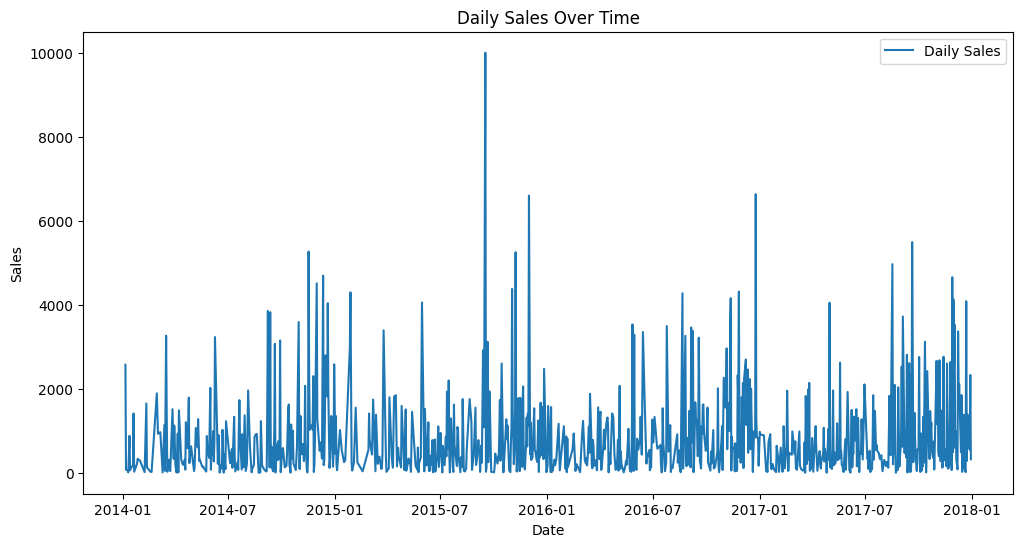

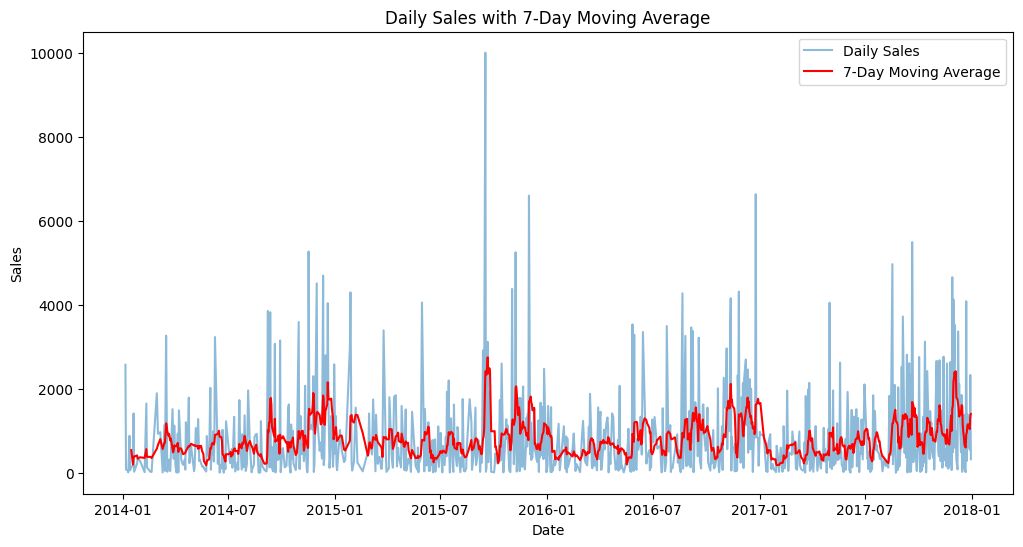

In [ ]:
import matplotlib.pyplot as plt

# Plot daily sales
plt.figure(figsize=(12,6))
plt.plot(sales_daily['Order Date'], sales_daily['Sales'], label='Daily Sales')
plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# Simple 7-day moving average forecast
sales_daily['7d_MA'] = sales_daily['Sales'].rolling(window=7).mean()

# Plot moving average
plt.figure(figsize=(12,6))
plt.plot(sales_daily['Order Date'], sales_daily['Sales'], alpha=0.5, label='Daily Sales')
plt.plot(sales_daily['Order Date'], sales_daily['7d_MA'], color='red', label='7-Day Moving Average')
plt.title("Daily Sales with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [ ]:
# Convert 'Order Date' to datetime (if not already)
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Calculate RFM values
import datetime as dt

snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (snapshot_date - x.max()).days,
    'Order ID': 'count',
    'Sales': 'sum'
})

rfm.rename(columns={
    'Order Date': 'Recency',
    'Order ID': 'Frequency',
    'Sales': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,1203,1,14.560
AA-10375,1062,1,28.400
AA-10480,492,2,475.300
AA-10645,483,8,3750.713
AB-10015,416,2,390.672


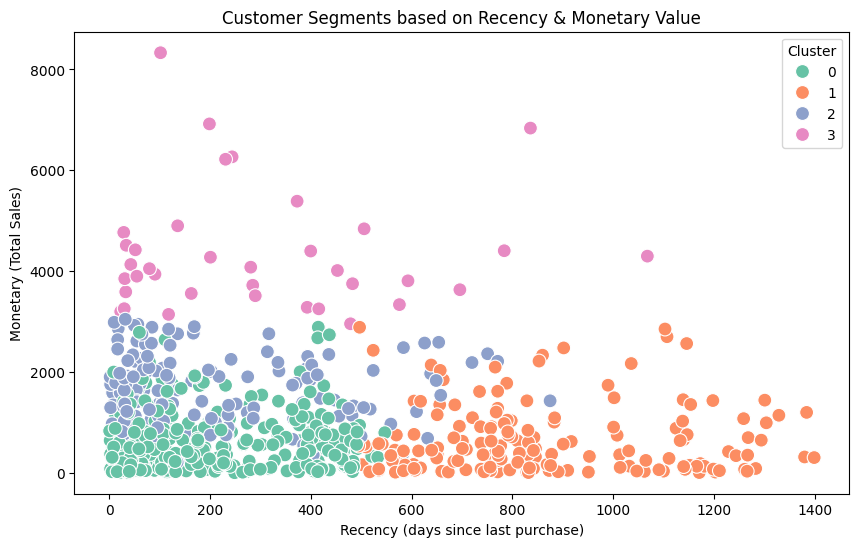

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Standardize RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Visualize clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x=rfm['Recency'], y=rfm['Monetary'], hue=rfm['Cluster'], palette='Set2', s=100)
plt.title("Customer Segments based on Recency & Monetary Value")
plt.xlabel("Recency (days since last purchase)")
plt.ylabel("Monetary (Total Sales)")
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

# Prepare time series
df_sales = df[['Order Date', 'Sales']].copy()
df_sales['Order Date'] = pd.to_datetime(df_sales['Order Date'])
df_sales.set_index('Order Date', inplace=True)
df_sales = df_sales.resample('M').sum()  # Monthly aggregation

# Train-test split
train = df_sales.iloc[:-12]
test = df_sales.iloc[-12:]

# Holt-Winters model (trend + seasonality)
model = ExponentialSmoothing(train['Sales'], trend='add', seasonal='add', seasonal_periods=12)
hw_model = model.fit()

# Forecast next 12 months
forecast = hw_model.forecast(12)

# Plot
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Test')
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.title("Monthly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
python -m pip install statsmodels

SyntaxError: invalid syntax (3357972877.py, line 1)

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [ ]:
import pandas as pd

# Make sure your CSV is already loaded
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Check the first 5 rows to confirm
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [ ]:
# Sum sales for each date
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

# Show the first few rows
daily_sales.head()

,Order Date,Sales
0,2014-01-06,2573.820
1,2014-01-07,76.728
2,2014-01-10,51.940
3,2014-01-11,9.940
4,2014-01-13,879.939


C:\Users\Pankaj Patil\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Pankaj Patil\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Pankaj Patil\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


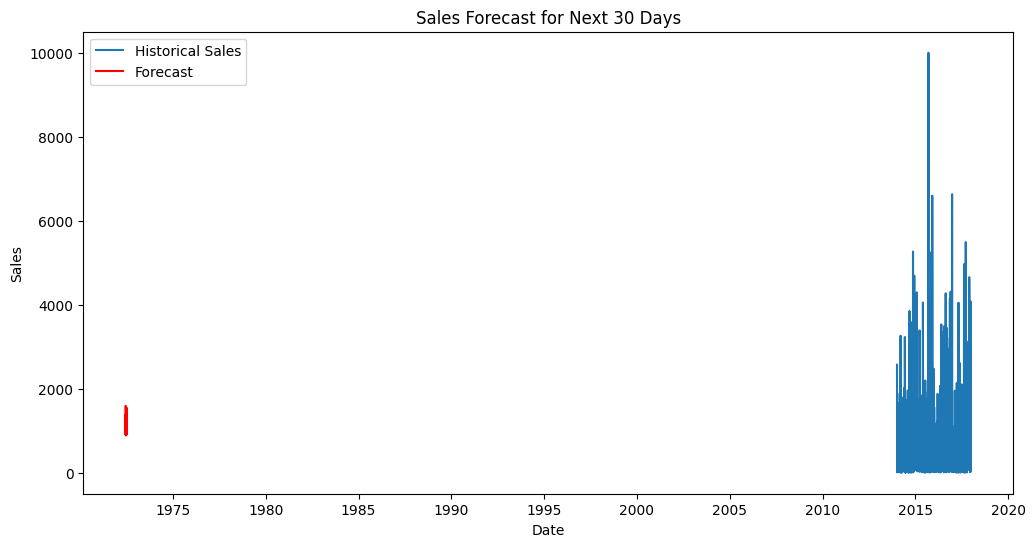

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

# Set Order Date as index
daily_sales.set_index('Order Date', inplace=True)

# Build the Holt-Winters model
model = ExponentialSmoothing(daily_sales['Sales'], trend='add', seasonal='add', seasonal_periods=30)
fit_model = model.fit()

# Forecast for next 30 days
forecast = fit_model.forecast(30)

# Plot original sales and forecast
plt.figure(figsize=(12,6))
plt.plot(daily_sales['Sales'], label='Historical Sales')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Sales Forecast for Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Selecting RFM columns
rfm_data = df_rfm[['Recency', 'Frequency', 'Monetary']]

# Standardize
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
df_rfm['Segment'] = kmeans.fit_predict(rfm_scaled)

# Check segment distribution
df_rfm['Segment'].value_counts()

NameError: name 'df_rfm' is not defined

In [ ]:
import pandas as pd

# Make sure 'Order Date' is datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Aggregate at customer level
df_rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (df['Order Date'].max() - x.max()).days,  # Recency
    'Order ID': 'count',                                               # Frequency
    'Sales': 'sum'                                                     # Monetary
})

# Rename columns
df_rfm.rename(columns={
    'Order Date': 'Recency',
    'Order ID': 'Frequency',
    'Sales': 'Monetary'
}, inplace=True)

df_rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,1202,1,14.560
AA-10375,1061,1,28.400
AA-10480,491,2,475.300
AA-10645,482,8,3750.713
AB-10015,415,2,390.672


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select RFM columns
rfm_data = df_rfm[['Recency', 'Frequency', 'Monetary']]

# Standardize
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

# Apply KMeans (4 clusters)
kmeans = KMeans(n_clusters=4, random_state=42)
df_rfm['Segment'] = kmeans.fit_predict(rfm_scaled)

# View cluster distribution
df_rfm['Segment'].value_counts()

Segment
0    340
1    170
2    161
3     36
Name: count, dtype: int64

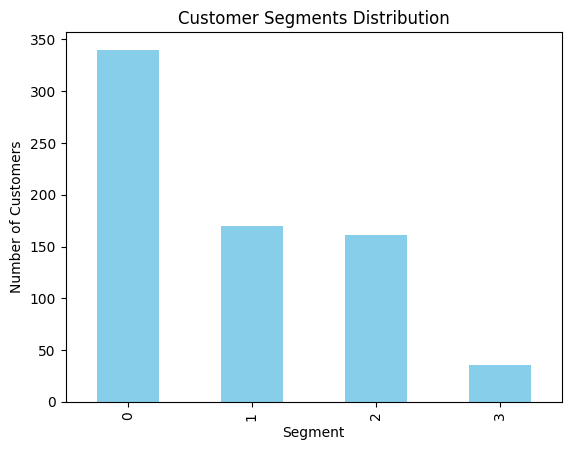

In [ ]:
import matplotlib.pyplot as plt

df_rfm['Segment'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

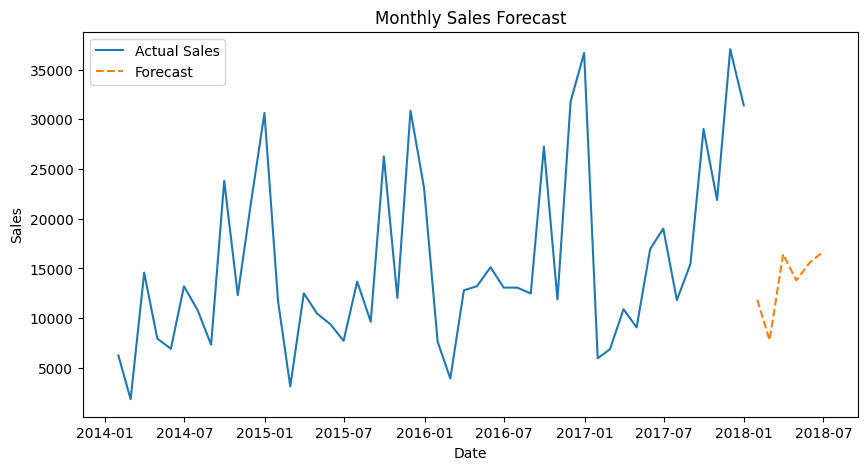

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

# Make sure 'Order Date' is datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Aggregate monthly sales using month-end frequency
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

# Fit Holt-Winters model
model = ExponentialSmoothing(monthly_sales, seasonal='add', seasonal_periods=12).fit()
forecast = model.forecast(6)  # Forecast next 6 months

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly_sales, label='Actual Sales')
plt.plot(forecast, label='Forecast', linestyle='--')
plt.title("Monthly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from datetime import datetime

# Make sure Order Date is datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Reference date for Recency (usually last date in dataset + 1 day)
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

# RFM Table
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Order ID': 'count',  # Frequency
    'Sales': 'sum'        # Monetary
}).reset_index()

rfm.rename(columns={'Order Date':'Recency', 'Order ID':'Frequency', 'Sales':'Monetary'}, inplace=True)
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,AA-10315,1203,1,14.560
1,AA-10375,1062,1,28.400
2,AA-10480,492,2,475.300
3,AA-10645,483,8,3750.713
4,AB-10015,416,2,390.672


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Standardize RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Segment'] = kmeans.fit_predict(rfm_scaled)

# Check segment counts
print(rfm['Segment'].value_counts())

Segment
0    340
1    170
2    161
3     36
Name: count, dtype: int64


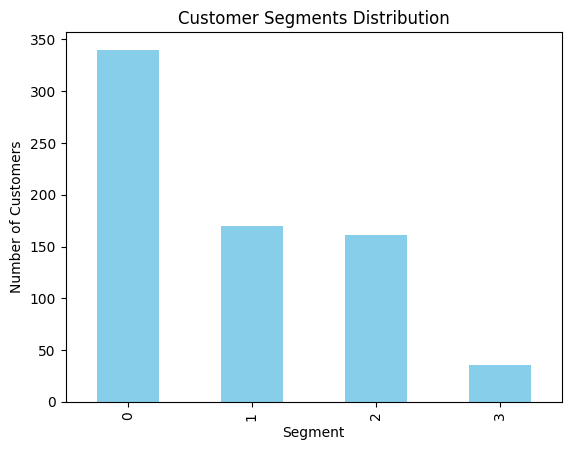

In [ ]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
import joblib

# Save the forecasting model
joblib.dump(model, "sales_forecasting_model.pkl")

['sales_forecasting_model.pkl']